<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-s-Assignments/blob/main/Intro__To_Machine_Learning_Assignment__6_%3CMuhammad_Zubayer%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Task 1: Data Loading and initial inspection.**

**Loading the Data**

In [ ]:
#importing pandas library
import pandas as pd
# mounting google drive in colab
from google.colab import drive
drive.mount('/content/drive')

source  = "/content/drive/MyDrive/Titinic /titanic.csv"
titanic = pd.read_csv(source)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Displying the first 5 rows to get quick look at the data structure**

In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Checking the data types of all coloums**

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Getting descripted statistics if the number of missing values for  each coloum**

In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Identifying the total number of missing values for each coloum**

In [ ]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


##**Task 2: Handeling the missing values**

In [3]:
#importing pandas library
import pandas as pd
# mounting google drive in colab
from google.colab import drive
drive.mount('/content/drive')

source  = "/content/drive/MyDrive/Titinic /titanic.csv"
titanic = pd.read_csv(source)



Mounted at /content/drive


**Calculating the percentage of missing values in the Cabin column**

In [18]:
Cabin_column_missing_percentage = (titanic["Cabin"].isnull().mean()) * 100
print(Cabin_column_missing_percentage)

77.10437710437711


`Comment:`Since 77.10% values are missing in the cabin column which is greater than 70% , we can not generate any meaningful relationship or insights using this column.So we have to drop the Cabin column from the dataframe.

**Finding the most frequent port of embarkation**

In [17]:
titanic["Embarked"].mode()

,Embarked
0,S


**Imputing the missing values in the Embarked column with the mode**

In [30]:
Filling_missing_value = titanic["Embarked"].fillna(titanic["Embarked"].mode() , inplace = True)
print(Filling_missing_value)

None


**Checking the percentage of  missing values of Embarked Column after imputing the missing values with mode**

In [32]:
Embarked_column_missing_percentage = (titanic["Embarked"].isnull().mean()/len(titanic))* 100
print(Embarked_column_missing_percentage)

0.00025192692607582245


Imputing the missing values in the Age column with the median age

In [27]:
#Displaying the median age
Median_age = titanic["Age"].median()
print(Median_age)

#Replacing the missing values with age column median
Imputing_age_missing_value = titanic["Age"].fillna(titanic["Age"].median(), inplace = True)
print(Imputing_age_missing_value)


28.0
None


/tmp/ipykernel_957/691308058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Imputing_age_missing_value = titanic["Age"].fillna(titanic["Age"].median(), inplace = True)


**Checking the percentage of  missing values of Age Column after imputing the missing values with mode**

In [33]:
Age_column_missing_percentage = (titanic["Age"].isnull().mean()/len(titanic))* 100
print(Age_column_missing_percentage)

0.0


##**Task 3: Univariate Analysis.**

**Calculating the overall survival rate (percentage of who survived)**

In [42]:
Survival_rate = (titanic["Survived"] == 1).mean() * 100
print(Survival_rate)

38.38383838383838


**Visualizing the distribution of Survived variable**

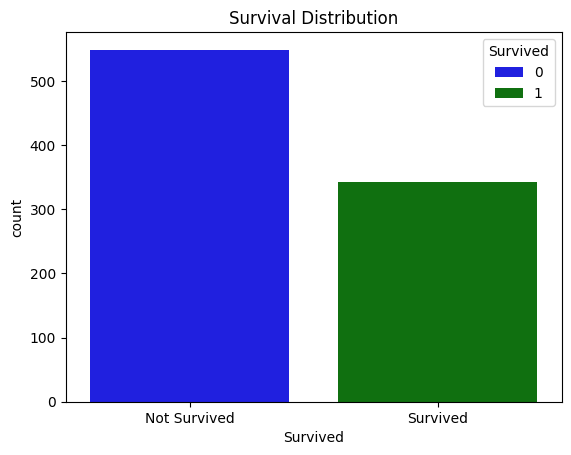

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
# Plot class distribution
sns.countplot(x='Survived', hue='Survived', data= titanic, palette=["blue", "green"])
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.title("Survival Distribution")
plt.show()

**Visualizing the distribution of Pclass using a count plot**

/tmp/ipykernel_957/3613910649.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=titanic, palette=["teal", "crimson", "navy"])


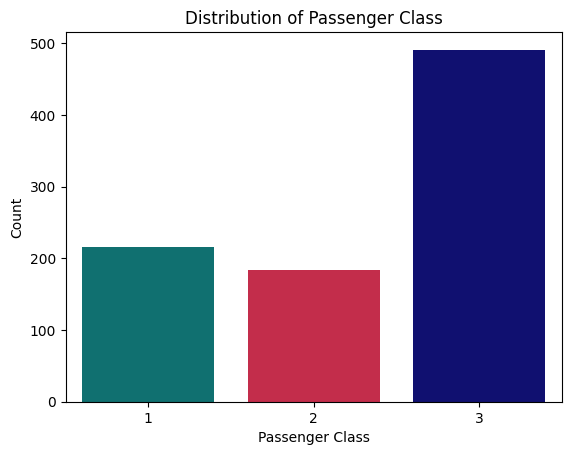

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Pclass", data=titanic, palette=["teal", "crimson", "navy"])
plt.title("Distribution of Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

**Visualizing the Histrogram of Age column**

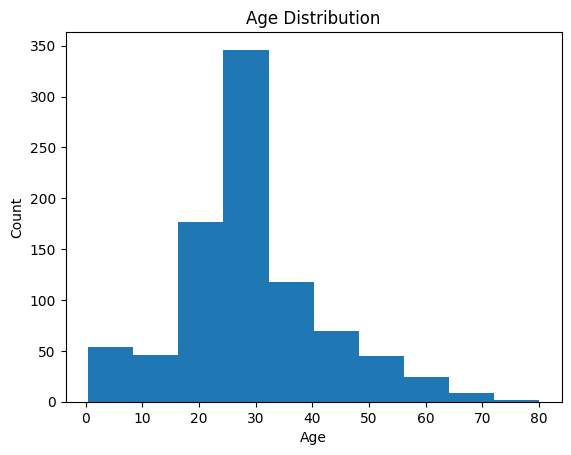

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.hist(titanic['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()